Name : Derap

E-mail :

### Module Import

In [41]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from keras.layers import Dense, Input, Dropout, BatchNormalization
from keras.models import Sequential
from keras import optimizers, regularizers
from sklearn.metrics import r2_score
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from keras.layers import Input, Dense

## Make a table in markdown :

```
| Architecture | Scaled | Epochs | mse  | val_mse | $R^2$ |
|--------------|--------|--------|------|---------|-------|
|              |        |        |      |         |       |
|              |        |        |      |         |       |
|              |        |        |      |         |       |
|              |        |        |      |         |       |
|              |        |        |      |         |       |
```

Note: The number of spaces used in this markdown table is just for visual formatting and is not mandatory. The table will render correctly even with minimal spacing.

will generate :
| Architecture | Scaled | Epochs | mse  | val_mse | $R^2$ |
|--------------|--------|--------|------|---------|-------|
|              |        |        |      |         |       |
|              |        |        |      |         |       |
|              |        |        |      |         |       |
|              |        |        |      |         |       |
|              |        |        |      |         |       |

### Local Functions

In [28]:
def read_fixed_width_file(file_path: str, skip_lines: int = 0) -> tuple[pd.DataFrame, dict[str, str]]:
    """
    Read a fixed-width file into a pandas DataFrame and return associated units.

    This function reads a specific fixed-width file format containing information about
    red giant stars. It creates a pandas DataFrame from the file contents and provides
    a dictionary of units for each column.

    :param file_path: Path to the fixed-width file.
    :type file_path: str
    :param skip_lines: Number of lines to skip at the beginning of the file, defaults to 0.
    :type skip_lines: int, optional

    :return: A tuple containing the pandas DataFrame and a dictionary of units.
    :rtype: Tuple[pd.DataFrame, Dict[str, str]]

    :raises FileNotFoundError: If the specified file_path does not exist.
    :raises pd.errors.EmptyDataError: If the file is empty.

    .. note::
        The file is expected to have the following columns:
        Type, 2MASS, Teff, log(g), [Fe/H], [a/Fe], lnM, lnAge, chi2, GALR,
        e_Teff, e_log(g), e_[Fe/H], e_[a/Fe], e_logM, e_logAge

    .. warning::
        This function is designed for a specific file format. Using it with different
        file formats may lead to unexpected results.

    Example:
        >>> file_path = 'path/to/your/apj523069t1_mrt.txt'
        >>> df, units = read_fixed_width_file(file_path, skip_lines=5)
        >>> print(df.head())
        >>> print(units)
    """
    # Define the column specifications
    col_specs = [
        (0, 8), (9, 16), (17, 21), (22, 26), (27, 33), (34, 39),
        (40, 44), (45, 49), (50, 55),
    ]

    # Define the column names
    col_names = [
        'RAdeg', 'Dedeg', 'Teff', 'log(g)', '[Fe/H]', '[a/Fe]',
        'mass_in', 'mass', 'age'
    ]

    # Define the units for each column
    units = {
        'Teff': 'K',
        'log(g)': '[cm/s2]',
        '[Fe/H]': '[Sun]',
        '[a/Fe]': '[Sun]',
        'mass_in': '[sol. Mass]',
        'mass': '[sol. Mass]',
        'age': '[Gyr]',
    }

    # Read the file using read_fwf function
    df = pd.read_fwf(file_path,
                     colspecs=col_specs,
                     names=col_names,
                     encoding='utf-8',
                     skiprows=skip_lines)

    return df, units


In [46]:
def scaled_train_test_split(df_train: pd.DataFrame, df_test: pd.DataFrame) -> tuple[pd.DataFrame, pd.DataFrame]:
    """
    Scale the training and test DataFrames using StandardScaler.

    This function applies StandardScaler to the input DataFrames, fitting the scaler
    on the training data and then transforming both training and test data.

    Parameters
    ----------
    df_train : pd.DataFrame
        The training DataFrame to be scaled.
    df_test : pd.DataFrame
        The test DataFrame to be scaled.

    Returns
    -------
    tuple[pd.DataFrame, pd.DataFrame]
        A tuple containing the scaled training DataFrame and the scaled test DataFrame.

    Raises
    ------
    ValueError
        If df_train and df_test do not have the same columns.
    AssertionError
        If either df_train or df_test is empty.

    Examples
    --------
    >>> train_df = pd.DataFrame({'A': [1, 2, 3], 'B': [4, 5, 6]})
    >>> test_df = pd.DataFrame({'A': [7, 8], 'B': [9, 10]})
    >>> scaled_train, scaled_test = scaled_train_test(train_df, test_df)
    """
    assert not df_train.empty, "Training DataFrame is empty"
    assert not df_test.empty, "Test DataFrame is empty"

    if not df_train.columns.equals(df_test.columns):
        raise ValueError("Training and test DataFrames must have the same columns")

    scaler = StandardScaler()
    scaled_df_train = pd.DataFrame(scaler.fit_transform(df_train), columns=df_train.columns)
    scaled_df_test = pd.DataFrame(scaler.transform(df_test), columns=df_test.columns)

    return scaled_df_train, scaled_df_test

### global variables

In [47]:
DATASET_URL = "https://content.cld.iop.org/journals/0067-0049/249/1/7/revision1/apjsab8bcdt8_mrt.txt"
RANDOM_SEED = 42

# Dataset Preparation

## downloading data

In [15]:
df_planets, units = read_fixed_width_file(DATASET_URL,20)

#Display the first few rows of the DataFrame to verify the data
print(df_planets.head())

#Display basic information about the DataFrame
print(units)

      RAdeg   Dedeg  Teff  log(g)  [Fe/H]  [a/Fe]  mass_in  mass   age
0  323.9122  7.4972  4085    1.39  -0.002    0.02     1.59  1.58  2.94
1  323.9490  0.5533  4685    2.84   0.070    0.16     1.02  1.07  9.07
2  324.0119  5.5206  4493    1.72  -0.431    0.02     1.27  1.47  1.92
3  324.0126  0.8406  4687    2.55   0.041    0.04     2.18  1.49  4.82
4  324.0231  3.7678  4622    2.66   0.236    0.06     1.31  1.41  4.11
{'Teff': 'K', 'log(g)': '[cm/s2]', '[Fe/H]': '[Sun]', '[a/Fe]': '[Sun]', 'mass_in': '[sol. Mass]', 'mass': '[sol. Mass]', 'age': '[Gyr]'}


In [16]:
#We split the data into 2 sub-datasets, 80% and 20% of the initial dataset. The 80% to train the model, 20% to test the model
from sklearn.model_selection import train_test_split
train, test = train_test_split(df_planets, test_size=0.2, random_state=70, shuffle=True)

X_train = train[['RAdeg', 'Dedeg', 'Teff', '[a/Fe]', 'mass', 'mass_in', 'log(g)', '[Fe/H]']]
X_test = test[['RAdeg', 'Dedeg', 'Teff', '[a/Fe]', 'mass', 'mass_in', 'log(g)', '[Fe/H]']]
y_train = train['age']
y_test = test['age']

print("Test Shape:", test.shape)
print("Train Shape:", train.shape)

Test Shape: (14636, 9)
Train Shape: (58544, 9)


In [17]:
def keras_model(input_shape, hidden_layers=[64, 128, 256, 512, 768]):
    model = Sequential()
    model.add(Input(shape=(input_shape,)))   # correct: use shape=

    for units in hidden_layers:
        model.add(Dense(units, activation='relu'))

    model.add(Dense(1))  # output layer
    return model

# build model: pass integer, NOT a tuple
model = keras_model(input_shape=X_train.shape[1],
                    hidden_layers=[64, 128, 256, 512, 768])

print("=== MODEL SUMMARY ===")
model.summary()


=== MODEL SUMMARY ===


Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_24 (Dense)                │ (None, 64)             │           576 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_25 (Dense)                │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_26 (Dense)                │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_27 (Dense)                │ (None, 512)            │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_28 (Dense)                │ (None, 768)            │       393,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_29 (Dense)                │ (None, 1)              │           769 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 568,257 (2.17 MB)

 Trainable params: 568,257 (2.17 MB)

 Non-trainable params: 0 (0.00 B)

In [18]:
# compile the model here
from tensorflow.keras.optimizers import AdamW

model.compile(
    optimizer=AdamW(learning_rate=0.001),
    loss='mse',
    metrics=['mse']
)


In [19]:
history = model.fit(
    X_train, y_train,    # Training data (features and targets)
    verbose=2,           # How much to print during training
    epochs=10,           # Number of complete passes through training data
    validation_data=(X_test, y_test)  # Data to evaluate after each epoch
)

Epoch 1/10
1830/1830 - 28s - 15ms/step - loss: 244.3715 - mse: 244.3715 - val_loss: 9.3110 - val_mse: 9.3110
Epoch 2/10
1830/1830 - 25s - 14ms/step - loss: 8.2047 - mse: 8.2047 - val_loss: 7.3420 - val_mse: 7.3420
Epoch 3/10
1830/1830 - 27s - 15ms/step - loss: 7.9357 - mse: 7.9357 - val_loss: 7.8023 - val_mse: 7.8023
Epoch 4/10
1830/1830 - 25s - 14ms/step - loss: 7.7009 - mse: 7.7009 - val_loss: 7.0225 - val_mse: 7.0225
Epoch 5/10
1830/1830 - 25s - 14ms/step - loss: 7.5015 - mse: 7.5015 - val_loss: 7.2648 - val_mse: 7.2648
Epoch 6/10
1830/1830 - 25s - 14ms/step - loss: 7.3493 - mse: 7.3493 - val_loss: 6.8046 - val_mse: 6.8046
Epoch 7/10
1830/1830 - 41s - 22ms/step - loss: 7.0927 - mse: 7.0927 - val_loss: 6.9166 - val_mse: 6.9166
Epoch 8/10
1830/1830 - 26s - 14ms/step - loss: 7.0601 - mse: 7.0601 - val_loss: 8.0705 - val_mse: 8.0705
Epoch 9/10
1830/1830 - 26s - 14ms/step - loss: 6.9788 - mse: 6.9788 - val_loss: 6.7602 - val_mse: 6.7602
Epoch 10/10
1830/1830 - 40s - 22ms/step - loss: 7.0

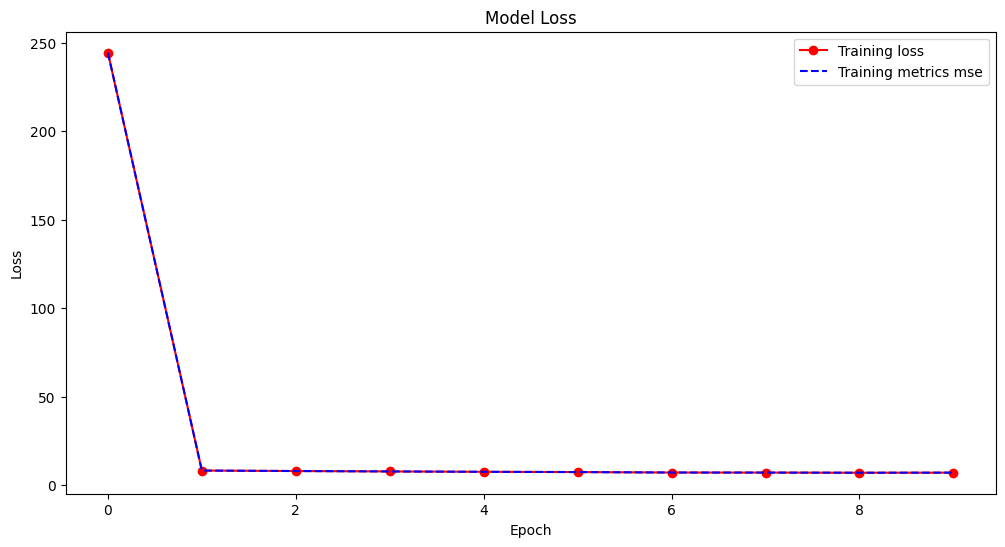

In [20]:
#Based on the "history" variable after training, we can estimate the "quality" for the model

#Plot training history
plt.figure(figsize=(12,6))
plt.plot(history.history['loss'], "o-", color='red', label = 'Training loss')
plt.plot(history.history['mse'], "--", color='blue', label = 'Training metrics mse')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [21]:
train_loss, train_mse= model.evaluate(X_train, y_train)
print("Train MSE:", train_mse)


test_loss, test_mse = model.evaluate(X_test, y_test)
print("Test MSE:", test_mse)


1830/1830 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - loss: 6.9594 - mse: 6.9594
Train MSE: 6.930775165557861
458/458 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 6.6157 - mse: 6.6157
Test MSE: 6.665177345275879


458/458 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step


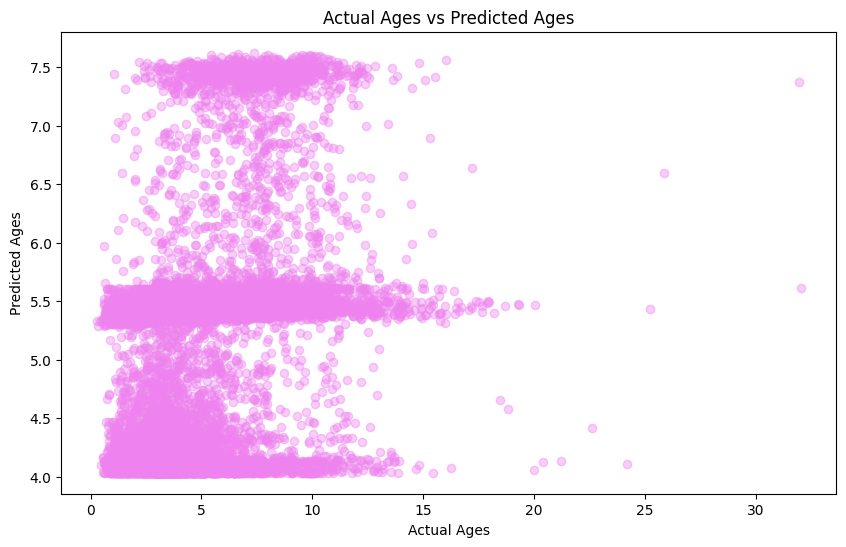

R²: 0.15471020069644148


In [22]:
#Generate prediction
y_pred = model.predict(X_test)

#Scatter plot of actual values vs predicted values
plt.figure(figsize=(10,6))
plt.scatter(y_test, y_pred, alpha=0.4, color='violet')
plt.title('Actual Ages vs Predicted Ages')
plt.xlabel('Actual Ages')
plt.ylabel('Predicted Ages')
plt.show()

#y_test and y_pred are the test data and predictions
r2 = r2_score(y_test, y_pred)

print("R²:", r2)

## Data splitting

# Simple Perceptron

      RAdeg   Dedeg  Teff  log(g)  [Fe/H]  [a/Fe]  mass_in  mass   age
0  323.9122  7.4972  4085    1.39  -0.002    0.02     1.59  1.58  2.94
1  323.9490  0.5533  4685    2.84   0.070    0.16     1.02  1.07  9.07
2  324.0119  5.5206  4493    1.72  -0.431    0.02     1.27  1.47  1.92
3  324.0126  0.8406  4687    2.55   0.041    0.04     2.18  1.49  4.82
4  324.0231  3.7678  4622    2.66   0.236    0.06     1.31  1.41  4.11
{'Teff': 'K', 'log(g)': '[cm/s2]', '[Fe/H]': '[Sun]', '[a/Fe]': '[Sun]', 'mass_in': '[sol. Mass]', 'mass': '[sol. Mass]', 'age': '[Gyr]'}


Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_30 (Dense)                │ (None, 64)             │           576 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_31 (Dense)                │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_32 (Dense)                │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_33 (Dense)                │ (None, 512)            │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_34 (Dense)                │ (None, 768)            │       393,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_35 (Dense)                │ (None, 1)              │           769 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 568,257 (2.17 MB)

 Trainable params: 568,257 (2.17 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
1830/1830 - 28s - 15ms/step - loss: 1.0890 - mse: 1.0890 - val_loss: 0.2715 - val_mse: 0.2715
Epoch 2/10
1830/1830 - 41s - 22ms/step - loss: 0.4194 - mse: 0.4194 - val_loss: 0.3101 - val_mse: 0.3101
Epoch 3/10
1830/1830 - 27s - 15ms/step - loss: 0.4471 - mse: 0.4471 - val_loss: 0.3063 - val_mse: 0.3063
Epoch 4/10
1830/1830 - 26s - 14ms/step - loss: 0.2953 - mse: 0.2953 - val_loss: 0.1405 - val_mse: 0.1405
Epoch 5/10
1830/1830 - 25s - 14ms/step - loss: 0.2530 - mse: 0.2530 - val_loss: 0.1196 - val_mse: 0.1196
Epoch 6/10
1830/1830 - 25s - 14ms/step - loss: 0.1957 - mse: 0.1957 - val_loss: 0.1606 - val_mse: 0.1606
Epoch 7/10
1830/1830 - 41s - 22ms/step - loss: 0.2738 - mse: 0.2738 - val_loss: 0.1344 - val_mse: 0.1344
Epoch 8/10
1830/1830 - 26s - 14ms/step - loss: 0.1767 - mse: 0.1767 - val_loss: 0.1216 - val_mse: 0.1216
Epoch 9/10
1830/1830 - 25s - 14ms/step - loss: 0.2077 - mse: 0.2077 - val_loss: 0.3108 - val_mse: 0.3108
Epoch 10/10
1830/1830 - 41s - 22ms/step - loss: 0.2009 

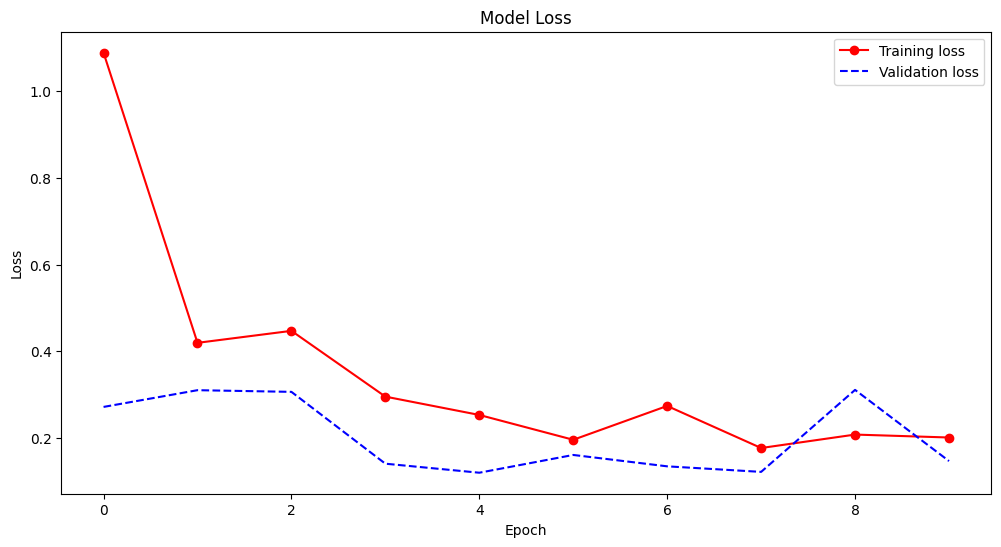

Train MSE: 0.1090
Test MSE: 0.1466
458/458 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step
R² on test set: 0.9810


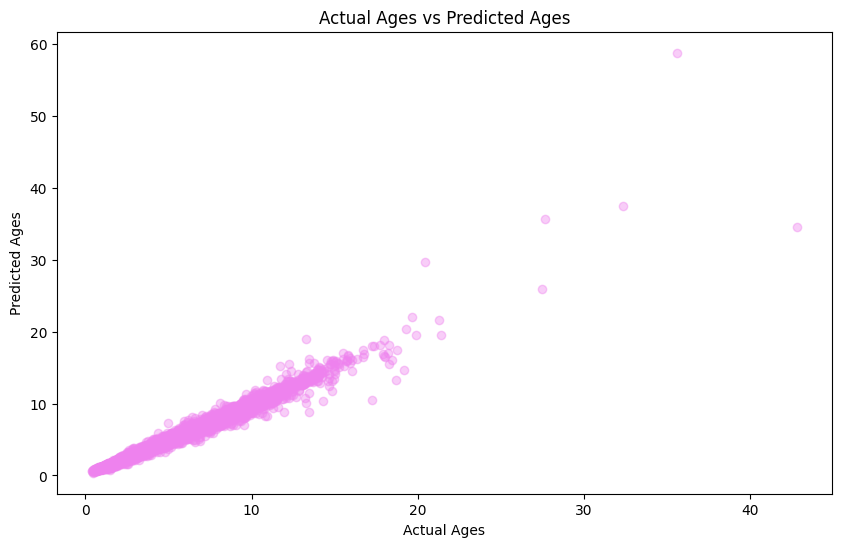

In [23]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras.optimizers import AdamW

# --- Load and preprocess data ---
DATASET_URL = "https://content.cld.iop.org/journals/0067-0049/249/1/7/revision1/apjsab8bcdt8_mrt.txt"

df_planets, units = read_fixed_width_file(DATASET_URL, skip_lines=20)
print(df_planets.head())
print(units)

train, test = train_test_split(df_planets, test_size=0.2, random_state=42, shuffle=True)

X_train = train[['RAdeg', 'Dedeg', 'Teff', '[a/Fe]', 'mass', 'mass_in', 'log(g)', '[Fe/H]']]
X_test = test[['RAdeg', 'Dedeg', 'Teff', '[a/Fe]', 'mass', 'mass_in', 'log(g)', '[Fe/H]']]
y_train = train['age']
y_test = test['age']

# Scale features
X_train_scaled, X_test_scaled = scaled_train_test_split(X_train, X_test)

# --- Build MLP model ---
def keras_model(input_shape, hidden_layers=[64, 128, 256, 512, 768]):
    model = Sequential()
    model.add(Input(shape=(input_shape,)))
    for units in hidden_layers:
        model.add(Dense(units, activation='relu'))
    model.add(Dense(1))  # Output layer
    return model

model = keras_model(input_shape=X_train_scaled.shape[1], hidden_layers=[64, 128, 256, 512, 768])
model.summary()

# Compile model with AdamW
model.compile(
    optimizer=AdamW(learning_rate=0.001),
    loss='mse',
    metrics=['mse']
)

# --- Train model ---
history = model.fit(
    X_train_scaled, y_train,
    epochs=10,  # You can increase epochs for better convergence
    validation_data=(X_test_scaled, y_test),
    verbose=2
)

# --- Plot training history ---
plt.figure(figsize=(12,6))
plt.plot(history.history['loss'], "o-", color='red', label='Training loss')
plt.plot(history.history['val_loss'], "--", color='blue', label='Validation loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

# --- Evaluate model ---
train_loss, train_mse = model.evaluate(X_train_scaled, y_train, verbose=0)
test_loss, test_mse= model.evaluate(X_test_scaled, y_test, verbose=0)
print(f"Train MSE: {train_mse:.4f}")
print(f"Test MSE: {test_mse:.4f}")

# --- Predictions and R² ---
y_pred = model.predict(X_test_scaled)
r2 = r2_score(y_test, y_pred)
print(f"R² on test set: {r2:.4f}")

# --- Scatter plot: actual vs predicted ---
plt.figure(figsize=(10,6))
plt.scatter(y_test, y_pred, alpha=0.4, color='violet')
plt.title('Actual Ages vs Predicted Ages')
plt.xlabel('Actual Ages')
plt.ylabel('Predicted Ages')
plt.show()


## Initial Model Architecture

      RAdeg   Dedeg  Teff  log(g)  [Fe/H]  [a/Fe]  mass_in  mass   age
0  323.9122  7.4972  4085    1.39  -0.002    0.02     1.59  1.58  2.94
1  323.9490  0.5533  4685    2.84   0.070    0.16     1.02  1.07  9.07
2  324.0119  5.5206  4493    1.72  -0.431    0.02     1.27  1.47  1.92
3  324.0126  0.8406  4687    2.55   0.041    0.04     2.18  1.49  4.82
4  324.0231  3.7678  4622    2.66   0.236    0.06     1.31  1.41  4.11
{'Teff': 'K', 'log(g)': '[cm/s2]', '[Fe/H]': '[Sun]', '[a/Fe]': '[Sun]', 'mass_in': '[sol. Mass]', 'mass': '[sol. Mass]', 'age': '[Gyr]'}


Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_42 (Dense)                │ (None, 64)             │           576 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_43 (Dense)                │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_44 (Dense)                │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_45 (Dense)                │ (None, 512)            │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_46 (Dense)                │ (None, 768)            │       393,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_47 (Dense)                │ (None, 1)              │           769 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 568,257 (2.17 MB)

 Trainable params: 568,257 (2.17 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
1830/1830 - 27s - 15ms/step - loss: 289.7039 - mse: 289.7039 - val_loss: 8.3763 - val_mse: 8.3763
Epoch 2/10
1830/1830 - 25s - 14ms/step - loss: 8.1742 - mse: 8.1742 - val_loss: 7.1891 - val_mse: 7.1891
Epoch 3/10
1830/1830 - 26s - 14ms/step - loss: 7.8270 - mse: 7.8270 - val_loss: 7.0176 - val_mse: 7.0176
Epoch 4/10
1830/1830 - 26s - 14ms/step - loss: 7.7528 - mse: 7.7528 - val_loss: 6.8302 - val_mse: 6.8302
Epoch 5/10
1830/1830 - 25s - 14ms/step - loss: 7.5505 - mse: 7.5505 - val_loss: 6.6857 - val_mse: 6.6857
Epoch 6/10
1830/1830 - 25s - 14ms/step - loss: 7.3910 - mse: 7.3910 - val_loss: 6.5996 - val_mse: 6.5996
Epoch 7/10
1830/1830 - 25s - 14ms/step - loss: 7.1685 - mse: 7.1685 - val_loss: 6.7320 - val_mse: 6.7320
Epoch 8/10
1830/1830 - 25s - 14ms/step - loss: 7.1054 - mse: 7.1054 - val_loss: 6.4203 - val_mse: 6.4203
Epoch 9/10
1830/1830 - 25s - 14ms/step - loss: 7.0818 - mse: 7.0818 - val_loss: 6.3441 - val_mse: 6.3441
Epoch 10/10
1830/1830 - 25s - 14ms/step - loss: 7.0

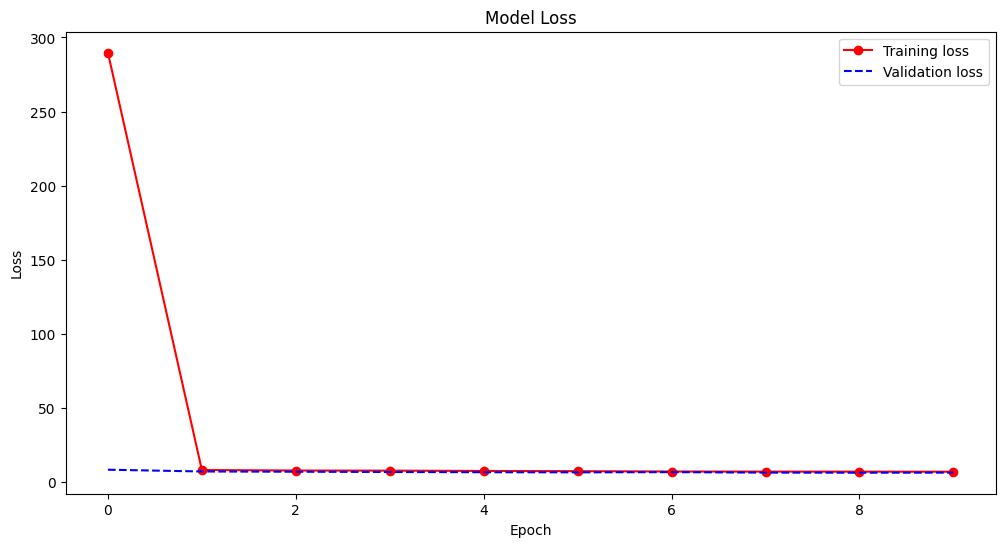

Train MSE: 6.8649
Test MSE: 6.4002
458/458 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step
R² on test set: 0.1715


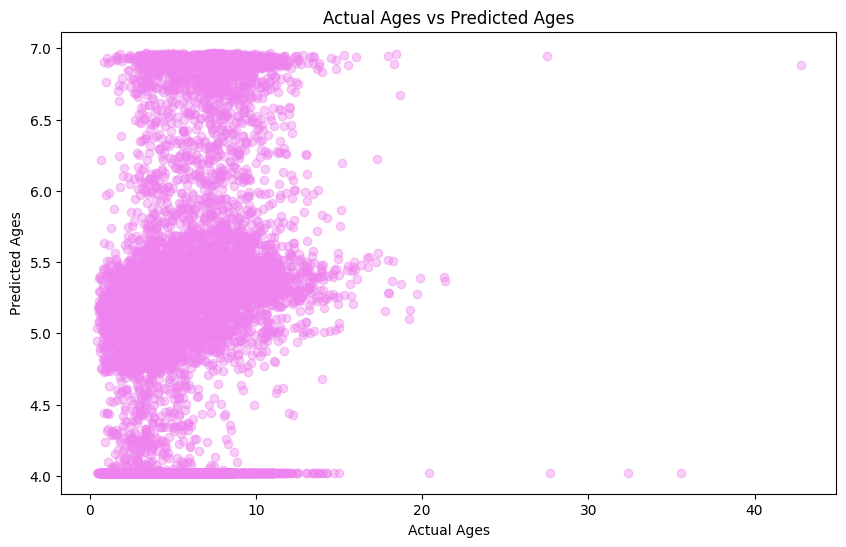

In [26]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras.optimizers import AdamW

# --- Load and preprocess data ---
DATASET_URL = "https://content.cld.iop.org/journals/0067-0049/249/1/7/revision1/apjsab8bcdt8_mrt.txt"

df_planets, units = read_fixed_width_file(DATASET_URL, skip_lines=20)
print(df_planets.head())
print(units)

train, test = train_test_split(df_planets, test_size=0.2, random_state=42, shuffle=True)

X_train = train[['RAdeg', 'Dedeg', 'Teff', '[a/Fe]', 'mass', 'mass_in', 'log(g)', '[Fe/H]']]
X_test = test[['RAdeg', 'Dedeg', 'Teff', '[a/Fe]', 'mass', 'mass_in', 'log(g)', '[Fe/H]']]
y_train = train['age']
y_test = test['age']

# --- Build MLP model ---
def keras_model(input_shape, hidden_layers=[64, 128, 256, 512, 768]):
    model = Sequential()
    model.add(Input(shape=(input_shape,)))
    for units in hidden_layers:
        model.add(Dense(units, activation='relu'))
    model.add(Dense(1))  # Output layer
    return model

# build model: pass integer, NOT a tuple
model = keras_model(input_shape=X_train.shape[1], hidden_layers=[64, 128, 256, 512, 768])

model.summary()

# Compile model with AdamW
model.compile(
    optimizer=AdamW(learning_rate=0.001),
    loss='mse',
    metrics=['mse']
)

# --- Train model ---
history = model.fit(
    X_train, y_train,
    epochs=10,  # You can increase epochs for better convergence
    validation_data=(X_test, y_test),
    verbose=2
)

# --- Plot training history ---
plt.figure(figsize=(12,6))
plt.plot(history.history['loss'], "o-", color='red', label='Training loss')
plt.plot(history.history['val_loss'], "--", color='blue', label='Validation loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

# --- Evaluate model ---
train_loss, train_mse = model.evaluate(X_train, y_train, verbose=0)
test_loss, test_mse= model.evaluate(X_test, y_test, verbose=0)
print(f"Train MSE: {train_mse:.4f}")
print(f"Test MSE: {test_mse:.4f}")

# --- Predictions and R² ---
y_pred = model.predict(X_test)
r2 = r2_score(y_test, y_pred)
print(f"R² on test set: {r2:.4f}")

# --- Scatter plot: actual vs predicted ---
plt.figure(figsize=(10,6))
plt.scatter(y_test, y_pred, alpha=0.4, color='violet')
plt.title('Actual Ages vs Predicted Ages')
plt.xlabel('Actual Ages')
plt.ylabel('Predicted Ages')
plt.show()


#Unscalling

In [33]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras.optimizers import AdamW

# --- Load and preprocess data ---
DATASET_URL = "https://content.cld.iop.org/journals/0067-0049/249/1/7/revision1/apjsab8bcdt8_mrt.txt"

df_planets, units = read_fixed_width_file(DATASET_URL, skip_lines=20)
print(df_planets.head())
print(units)

train, test = train_test_split(df_planets, test_size=0.2, random_state=42, shuffle=True)

X_train = train[['RAdeg', 'Dedeg', 'Teff', '[a/Fe]', 'mass', 'mass_in', 'log(g)', '[Fe/H]']]
X_test = test[['RAdeg', 'Dedeg', 'Teff', '[a/Fe]', 'mass', 'mass_in', 'log(g)', '[Fe/H]']]
y_train = train['age']
y_test = test['age']

# Scale features
X_train_scaled, X_test_scaled = scaled_train_test_split(X_train, X_test)

      RAdeg   Dedeg  Teff  log(g)  [Fe/H]  [a/Fe]  mass_in  mass   age
0  323.9122  7.4972  4085    1.39  -0.002    0.02     1.59  1.58  2.94
1  323.9490  0.5533  4685    2.84   0.070    0.16     1.02  1.07  9.07
2  324.0119  5.5206  4493    1.72  -0.431    0.02     1.27  1.47  1.92
3  324.0126  0.8406  4687    2.55   0.041    0.04     2.18  1.49  4.82
4  324.0231  3.7678  4622    2.66   0.236    0.06     1.31  1.41  4.11
{'Teff': 'K', 'log(g)': '[cm/s2]', '[Fe/H]': '[Sun]', '[a/Fe]': '[Sun]', 'mass_in': '[sol. Mass]', 'mass': '[sol. Mass]', 'age': '[Gyr]'}



=== Training constant model ===


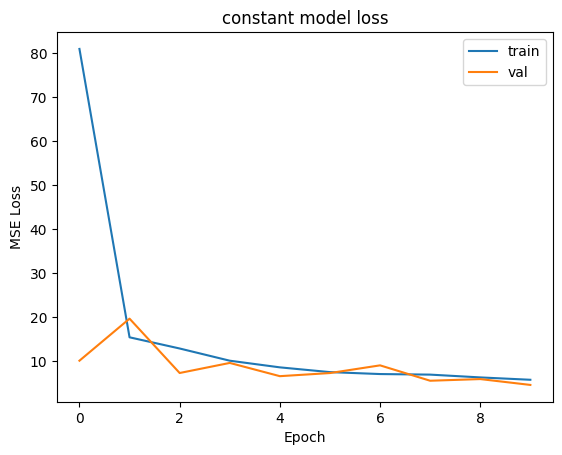

458/458 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
constant model: MSE = 4.5778, R² = 0.4074

=== Training expanding model ===


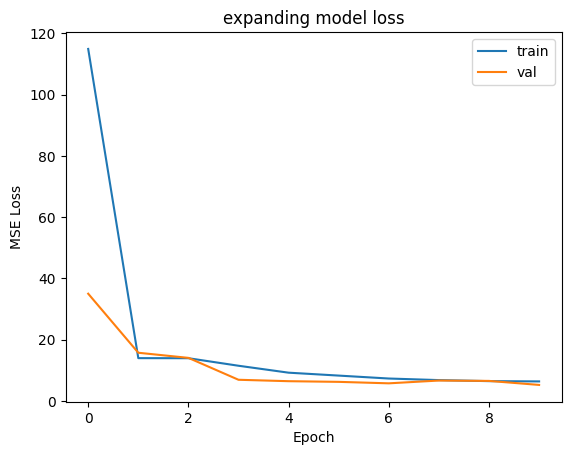

458/458 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
expanding model: MSE = 5.1902, R² = 0.3281

=== Training narrowing model ===


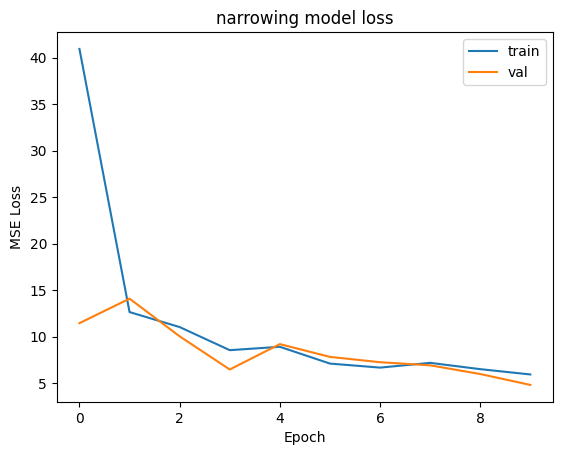

458/458 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
narrowing model: MSE = 4.7984, R² = 0.3789

=== Training hourglass model ===


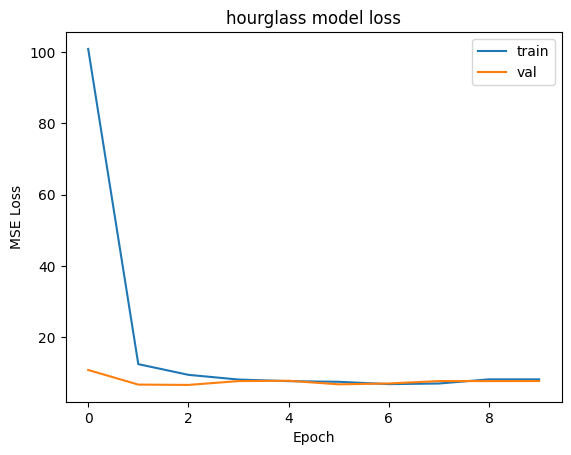

458/458 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step
hourglass model: MSE = 7.7334, R² = -0.0011

=== Training funnel model ===


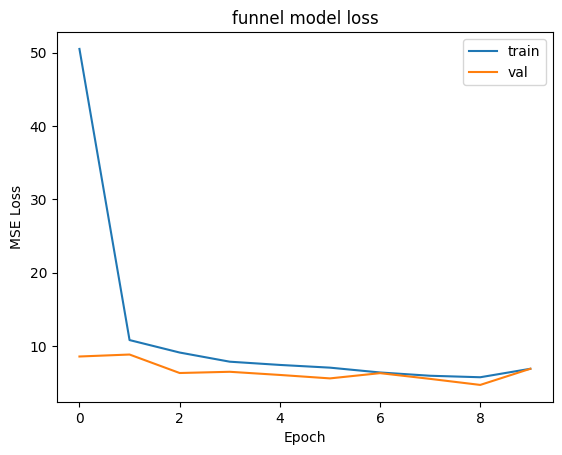

458/458 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
funnel model: MSE = 6.8971, R² = 0.1072


In [35]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, r2_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras.optimizers import AdamW

# --- Model builder ---
def build_model(input_dim, layer_structure):
    model = Sequential()
    model.add(Input(shape=(input_dim,)))

    for units in layer_structure:
        model.add(Dense(units, activation='relu'))

    model.add(Dense(1))  # output layer
    model.compile(optimizer=AdamW(learning_rate=0.001), loss='mse')
    return model

# --- Define architectures ---
architectures = {
    "constant": [64, 64, 64],
    "expanding": [32, 64, 128],
    "narrowing": [128, 64, 32],
    "hourglass": [128, 64, 128],
    "funnel": [256, 128, 64, 32]
}

results = {}

# --- Train and evaluate ---
for name, layers in architectures.items():
    print(f"\n=== Training {name} model ===")
    model = build_model(input_dim=X_train.shape[1], layer_structure=layers)

    history = model.fit(
        X_train, y_train,
        validation_data=(X_test, y_test),
        epochs=10, batch_size=32, verbose=0
    )

    # Plot training/validation loss
    plt.plot(history.history['loss'], label='train')
    plt.plot(history.history['val_loss'], label='val')
    plt.title(f'{name} model loss')
    plt.xlabel('Epoch')
    plt.ylabel('MSE Loss')
    plt.legend()
    plt.show()

    # Predict and evaluate
    y_pred = model.predict(X_test).flatten()
    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    print(f"{name} model: MSE = {mse:.4f}, R² = {r2:.4f}")

    results[name] = {"mse": mse, "r2": r2, "history": history.history}


458/458 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


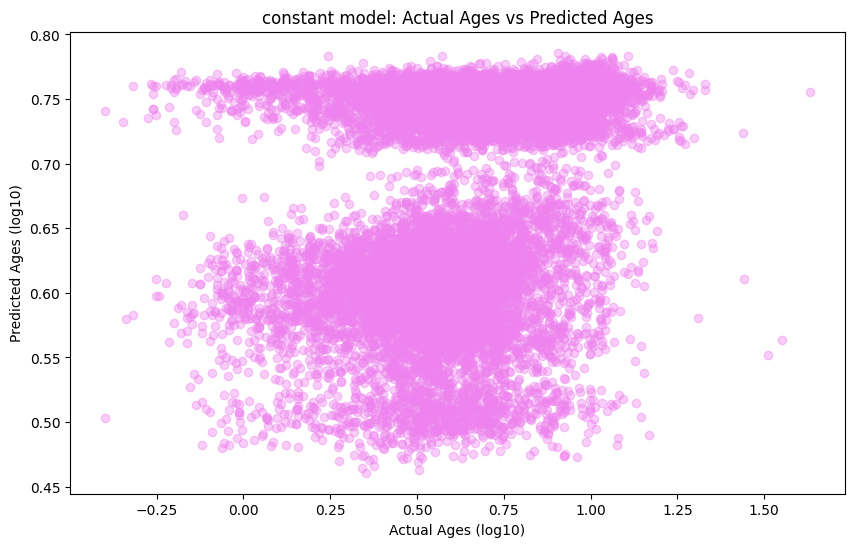

458/458 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


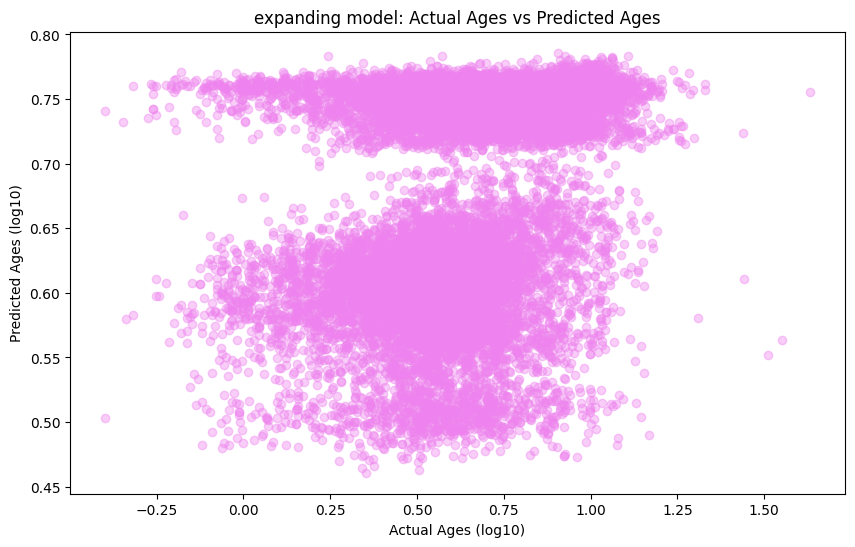

458/458 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


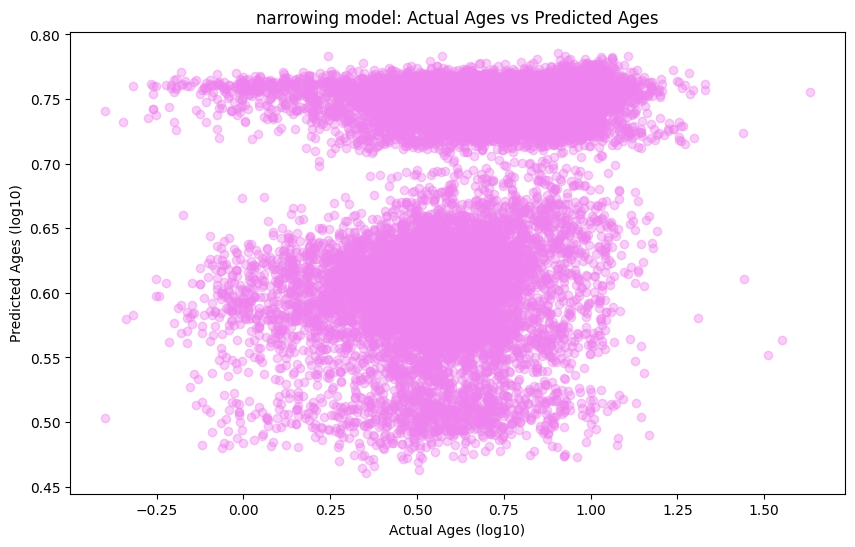

458/458 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


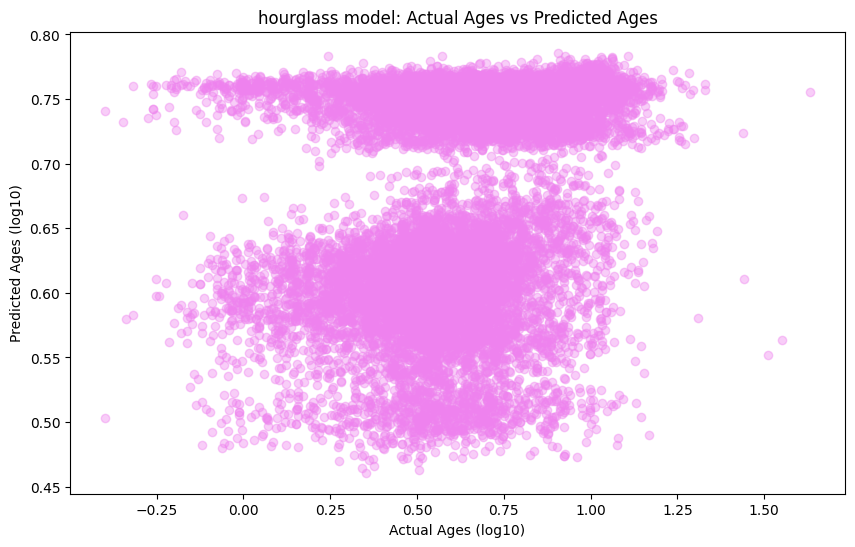

458/458 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


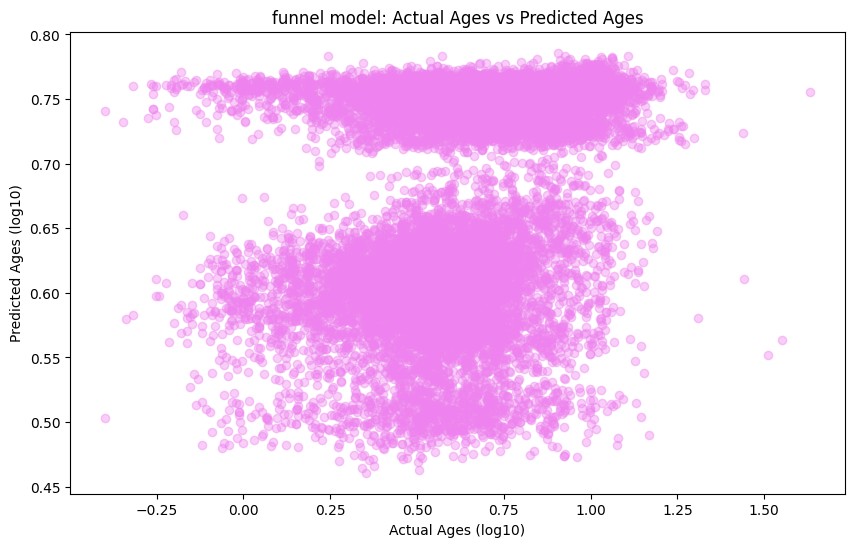

In [38]:
import matplotlib.pyplot as plt
import numpy as np

# Assuming 'results' dictionary from previous training code
for name, res in results.items():
    # Get predictions
    y_pred = model.predict(X_test).flatten()  # use the correct model if storing separately

    # Scatter plot in log scale
    plt.figure(figsize=(10, 6))
    plt.scatter(np.log10(y_test), np.log10(y_pred), alpha=0.4, color='violet')
    plt.title(f'{name} model: Actual Ages vs Predicted Ages')
    plt.xlabel('Actual Ages (log10)')
    plt.ylabel('Predicted Ages (log10)')
    plt.show()


#Scalling

      RAdeg   Dedeg  Teff  log(g)  [Fe/H]  [a/Fe]  mass_in  mass   age
0  323.9122  7.4972  4085    1.39  -0.002    0.02     1.59  1.58  2.94
1  323.9490  0.5533  4685    2.84   0.070    0.16     1.02  1.07  9.07
2  324.0119  5.5206  4493    1.72  -0.431    0.02     1.27  1.47  1.92
3  324.0126  0.8406  4687    2.55   0.041    0.04     2.18  1.49  4.82
4  324.0231  3.7678  4622    2.66   0.236    0.06     1.31  1.41  4.11
{'Teff': 'K', 'log(g)': '[cm/s2]', '[Fe/H]': '[Sun]', '[a/Fe]': '[Sun]', 'mass_in': '[sol. Mass]', 'mass': '[sol. Mass]', 'age': '[Gyr]'}

=== Training constant model ===


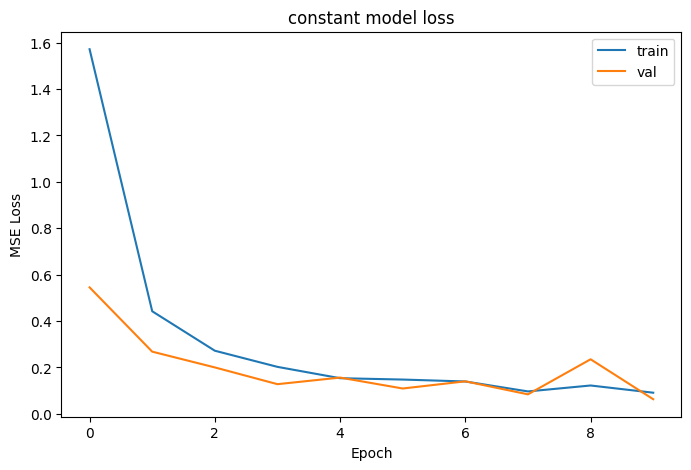

458/458 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
constant model: MSE = 0.0630, R² = 0.9918


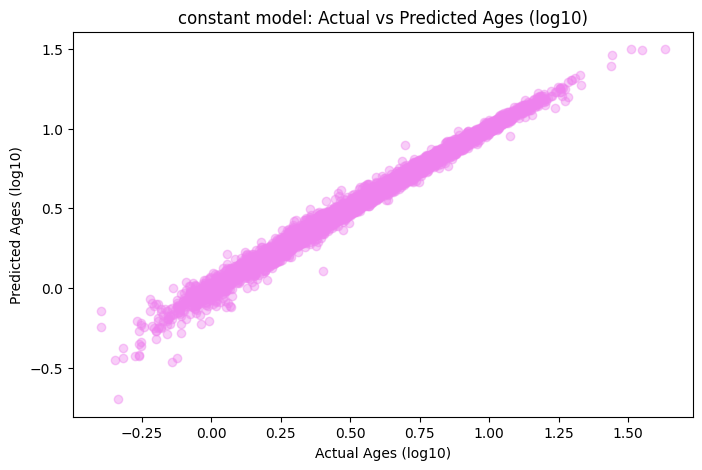


=== Training expanding model ===


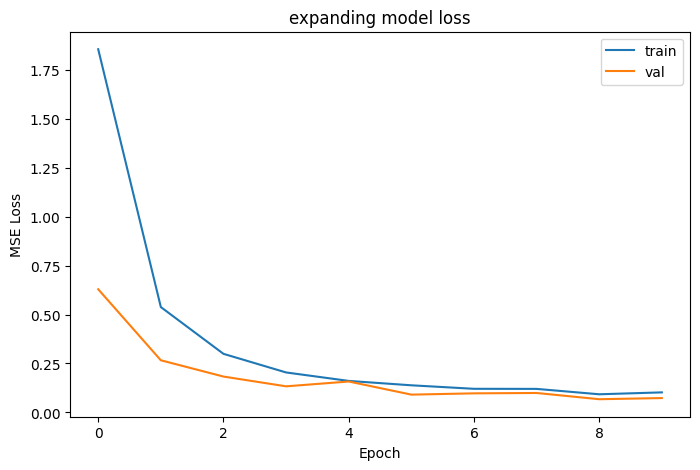

458/458 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
expanding model: MSE = 0.0733, R² = 0.9905


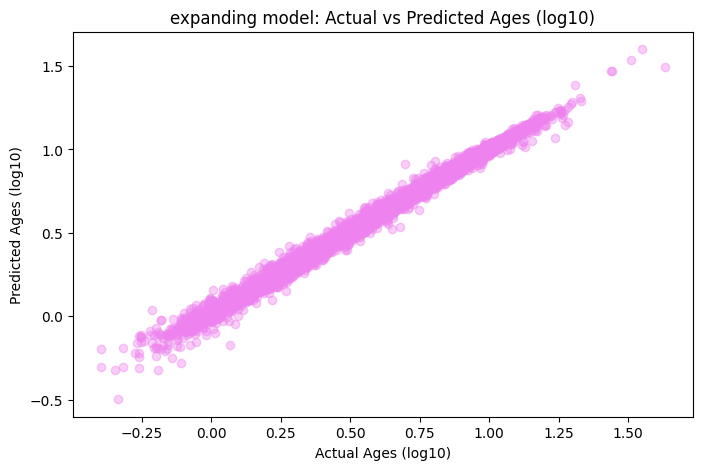


=== Training narrowing model ===


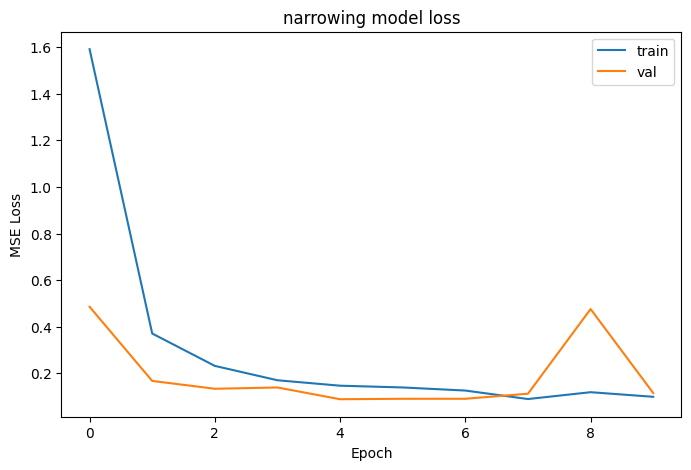

458/458 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
narrowing model: MSE = 0.1157, R² = 0.9850


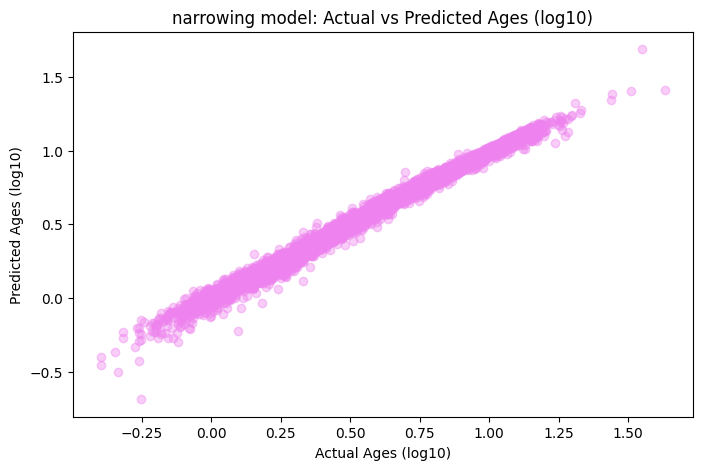


=== Training hourglass model ===


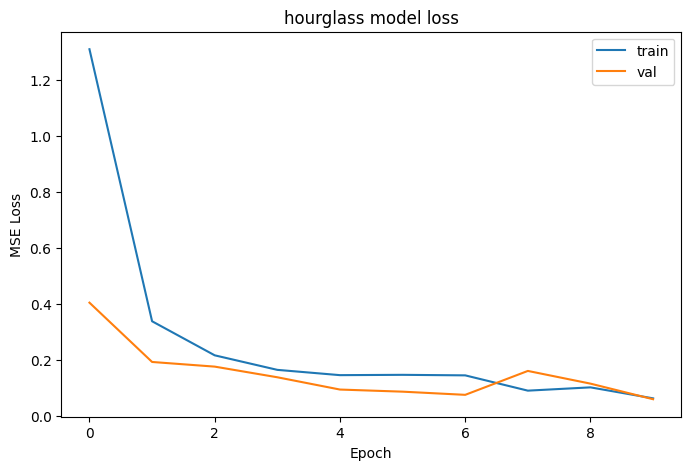

458/458 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
hourglass model: MSE = 0.0597, R² = 0.9923


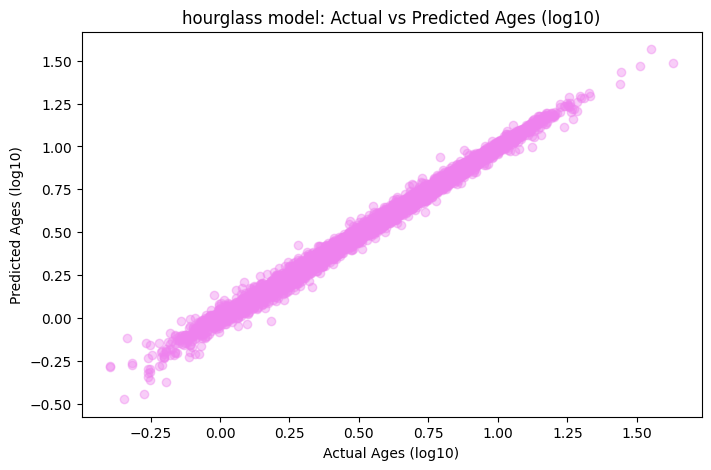


=== Training funnel model ===


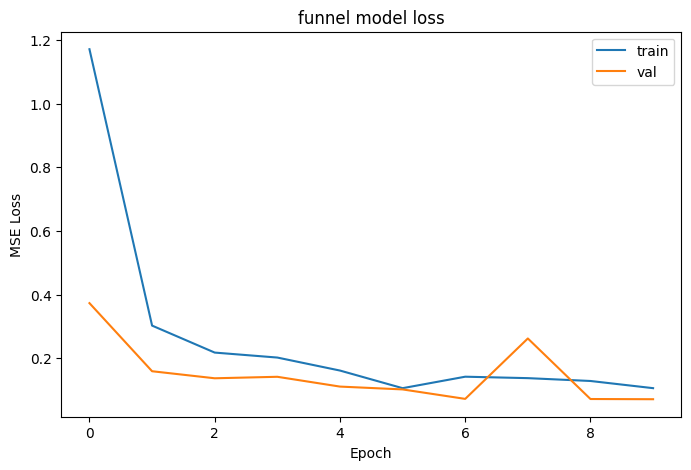

458/458 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
funnel model: MSE = 0.0715, R² = 0.9907


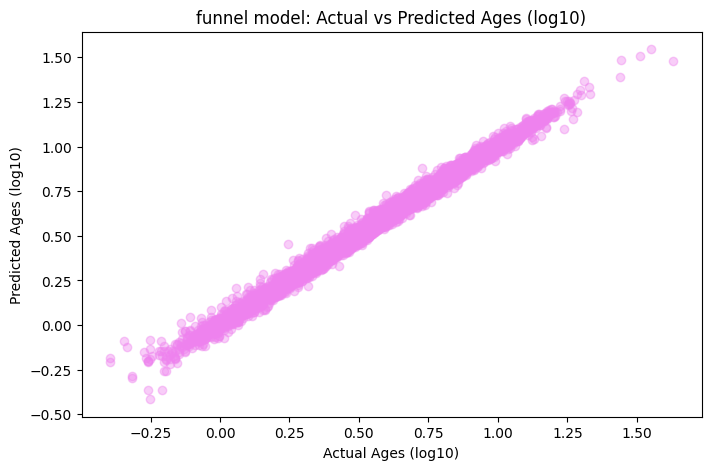

In [48]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras.optimizers import AdamW
from tensorflow.keras import regularizers

df_planets, units = read_fixed_width_file(DATASET_URL,20)

#Display the first few rows of the DataFrame to verify the data
print(df_planets.head())

#Display basic information about the DataFrame
print(units)

# --- Scale features ---
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns)
X_test_scaled  = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns)

# --- Model builder using Adam + L2 (mimics AdamW) ---
def build_model(input_dim, layer_structure, weight_decay=1e-4):
    model = Sequential()
    model.add(Input(shape=(input_dim,)))

    for units in layer_structure:
        model.add(Dense(units, activation='relu'))

    model.add(Dense(1))  # output layer
    optimizer = AdamW(learning_rate=0.001)
    model.compile(optimizer=optimizer, loss='mse')
    return model

# --- Define architectures ---
architectures = {
    "constant": [64, 64, 64],
    "expanding": [32, 64, 128],
    "narrowing": [128, 64, 32],
    "hourglass": [128, 64, 128],
    "funnel": [256, 128, 64, 32]
}

results = {}

# --- Train, evaluate, plot ---
for name, layers in architectures.items():
    print(f"\n=== Training {name} model ===")
    model = build_model(input_dim=X_train_scaled.shape[1], layer_structure=layers)

    history = model.fit(
        X_train_scaled, y_train,
        validation_data=(X_test_scaled, y_test),
        epochs=10, batch_size=32, verbose=0
    )

    # Plot loss
    plt.figure(figsize=(8,5))
    plt.plot(history.history['loss'], label='train')
    plt.plot(history.history['val_loss'], label='val')
    plt.title(f'{name} model loss')
    plt.xlabel('Epoch')
    plt.ylabel('MSE Loss')
    plt.legend()
    plt.show()

    # Predict and evaluate
    y_pred = model.predict(X_test_scaled).flatten()
    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    print(f"{name} model: MSE = {mse:.4f}, R² = {r2:.4f}")

    # Scatter plot of actual vs predicted ages (log scale)
    plt.figure(figsize=(8,5))
    plt.scatter(np.log10(y_test+1e-3), np.log10(y_pred+1e-3), alpha=0.4, color='violet')
    plt.title(f'{name} model: Actual vs Predicted Ages (log10)')
    plt.xlabel('Actual Ages (log10)')
    plt.ylabel('Predicted Ages (log10)')
    plt.show()

    results[name] = {"mse": mse, "r2": r2, "history": history.history, "y_pred": y_pred}


#Not Log AdamW


=== Training constant model ===


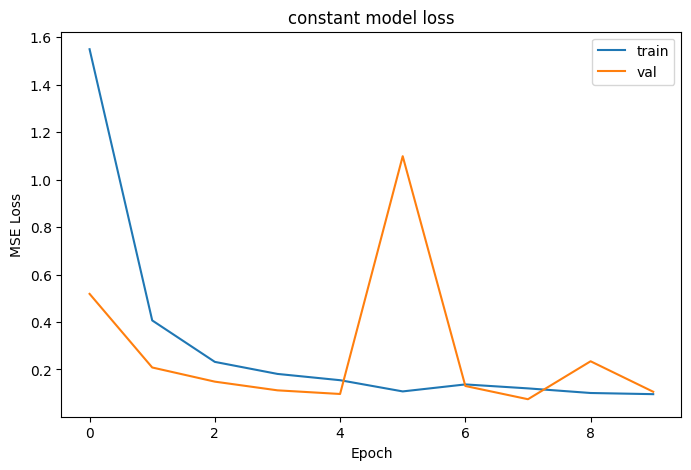

458/458 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
constant model: MSE = 0.1060, R² = 0.9863


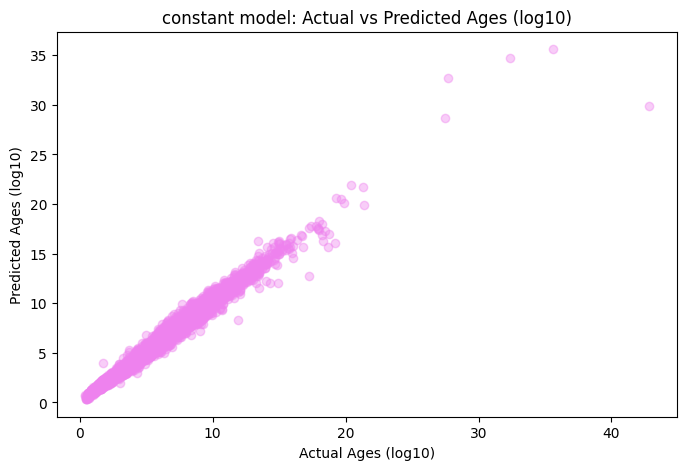


=== Training expanding model ===


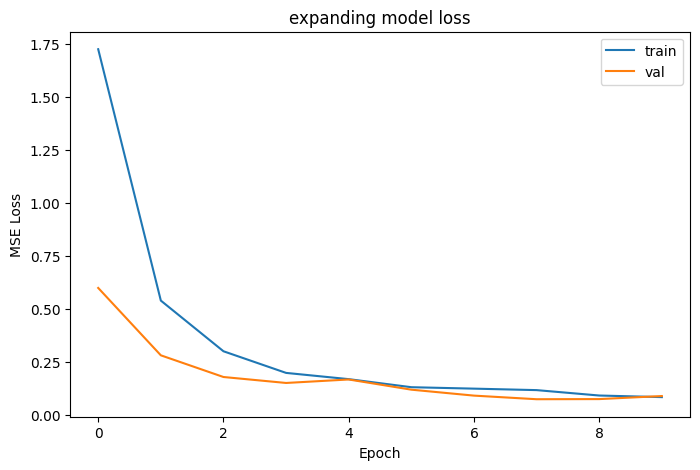

458/458 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
expanding model: MSE = 0.0894, R² = 0.9884


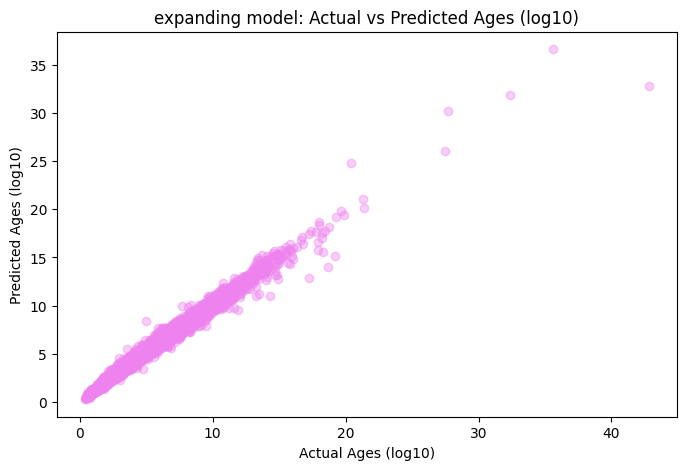


=== Training narrowing model ===


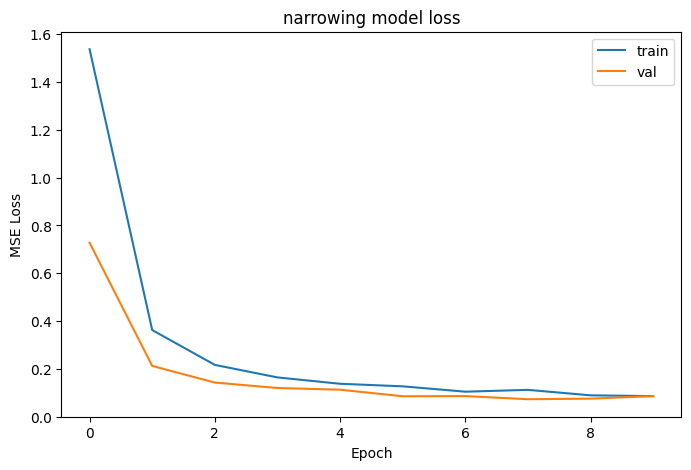

458/458 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
narrowing model: MSE = 0.0854, R² = 0.9889


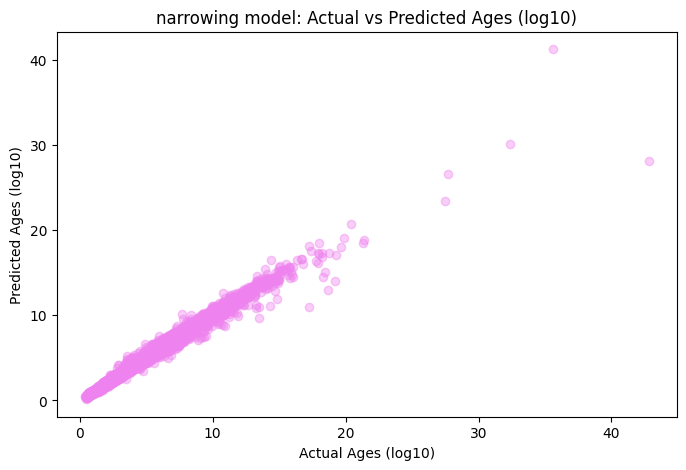


=== Training hourglass model ===


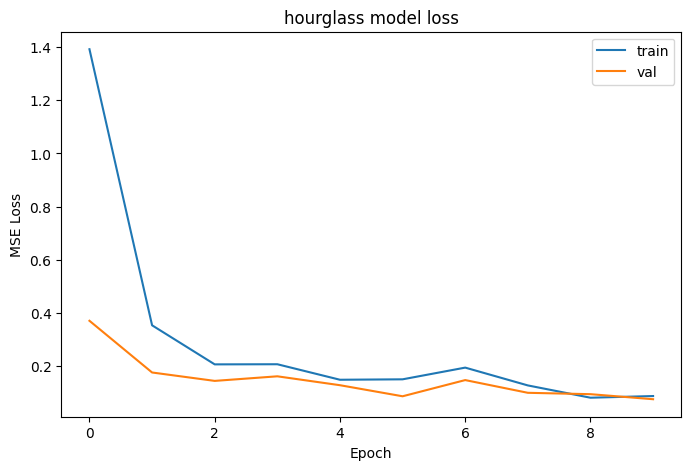

458/458 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
hourglass model: MSE = 0.0747, R² = 0.9903


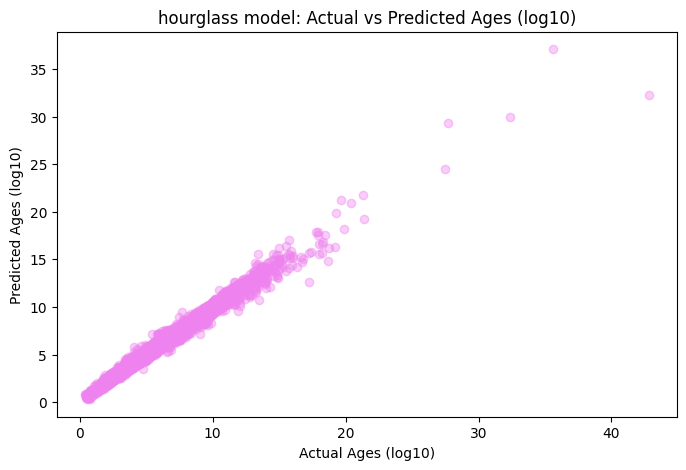


=== Training funnel model ===


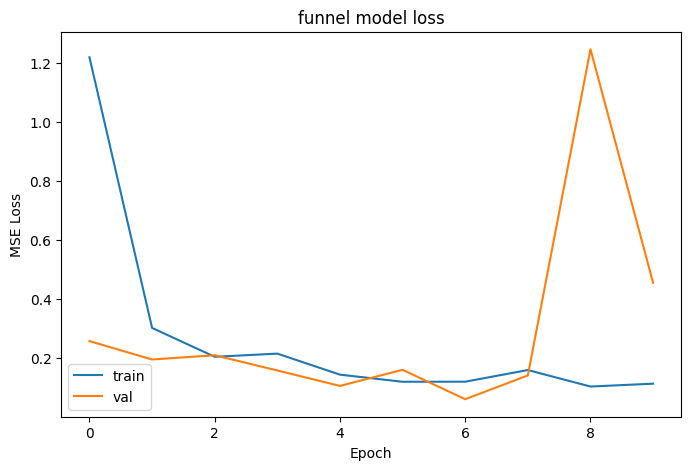

458/458 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
funnel model: MSE = 0.4556, R² = 0.9410


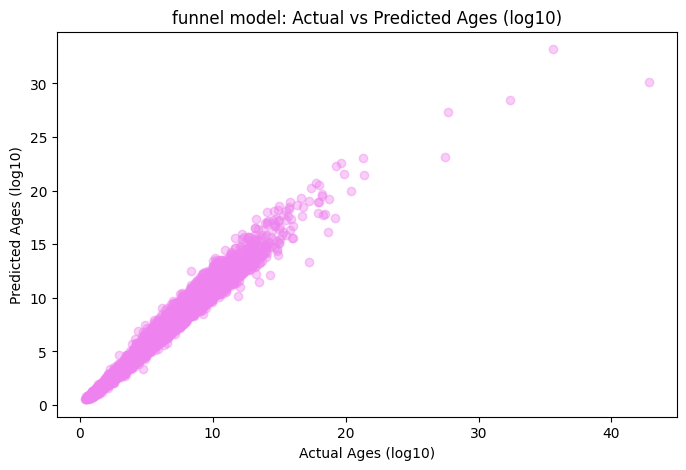

In [45]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras.optimizers import AdamW  # TF 2.19

# --- Scale features ---
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns)
X_test_scaled  = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns)

# --- Model builder using TF 2.19 AdamW ---
def build_model(input_dim, layer_structure, weight_decay=1e-4):
    model = Sequential()
    model.add(Input(shape=(input_dim,)))

    for units in layer_structure:
        model.add(Dense(units, activation='relu',
                        kernel_regularizer=None))  # optional: regularization inside layer
    model.add(Dense(1))

    optimizer = AdamW(learning_rate=0.001, weight_decay=weight_decay)
    model.compile(optimizer=optimizer, loss='mse', metrics=['mse', 'mae'])
    return model

# --- Define architectures ---
architectures = {
    "constant": [64, 64, 64],
    "expanding": [32, 64, 128],
    "narrowing": [128, 64, 32],
    "hourglass": [128, 64, 128],
    "funnel": [256, 128, 64, 32]
}

results = {}

# --- Train, evaluate, plot ---
for name, layers in architectures.items():
    print(f"\n=== Training {name} model ===")
    model = build_model(input_dim=X_train_scaled.shape[1], layer_structure=layers)

    history = model.fit(
        X_train_scaled, y_train,
        validation_data=(X_test_scaled, y_test),
        epochs=10, batch_size=32, verbose=0
    )

    # Plot training/validation loss
    plt.figure(figsize=(8,5))
    plt.plot(history.history['loss'], label='train')
    plt.plot(history.history['val_loss'], label='val')
    plt.title(f'{name} model loss')
    plt.xlabel('Epoch')
    plt.ylabel('MSE Loss')
    plt.legend()
    plt.show()

    # Predict and evaluate
    y_pred = model.predict(X_test_scaled).flatten()
    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    print(f"{name} model: MSE = {mse:.4f}, R² = {r2:.4f}")

    # Scatter plot (log10)
    plt.figure(figsize=(8,5))
    plt.scatter(y_test, y_pred, alpha=0.4, color='violet')
    plt.title(f'{name} model: Actual vs Predicted Ages (log10)')
    plt.xlabel('Actual Ages (log10)')
    plt.ylabel('Predicted Ages (log10)')
    plt.show()

    results[name] = {
        "mse_train": history.history['loss'][-1],
        "mse_val": history.history['val_loss'][-1],
        "r2": r2,
        "history": history.history,
        "y_pred": y_pred
    }


# NEW